### Introduction

Vampire example:

$$ Pr(\text{vampire|positive}) = \frac{Pr(\text{positive|vampire})Pr(\text{vampire})}{Pr(\text{positive|vampire})Pr(\text{vampire}) + Pr(\text{positive|mortal})(1-Pr{vampire})} $$
$$ = \frac{0.95*0.001}{(0.95*0.001)+(0.01 * (1-0.001))} $$

Code to calculate it in Python:

In [1]:
pr_positive_vampire = 0.95
pr_positive_mortal = 0.01
pr_vampire = 0.001
pr_positive = pr_positive_vampire * pr_vampire + pr_positive_mortal * (1-pr_vampire)
pr_vampire_positive = pr_positive_vampire*pr_vampire/pr_positive
pr_vampire_positive

0.08683729433272395

This shows that when the condition of interest is very rare, having a test that finds the true cases is no guarantee that the positive result carries much information since most are false positives. 

Can you counts to display the same information

$$ pr(\text{vampire|positive})=\frac{95}{1094=0.087} $$

This is called the *frequency format* or *natural frequencies*

Thinking Bayesian -> we can exploit this format by taking probability distributions and sampling from them to produce counts
 * Can also draw samples from the posterior distribution -> sampled events are parameter values

### 3.1 Sampling from a grid-approximate posterior

Before we sample from the posterior, we need to make one, Using the Globe tossing model and grid approximation, let's create the posterior for when 6 water's are seen in 9 tosses:

In [53]:
import numpy as np
import pyro.distributions as distr
import torch

def dbinom(x: int, size: int, prob: np.array, log_p: bool = False) -> torch.tensor:
    """Recreation of dbinom from R using PyTorch and Pyro"""
    m = distr.Binomial(total_count=size, probs=torch.from_numpy(prob))
    if log_p:
        return m.log_probs(torch.tensor(x))
    else:
        return m.log_prob(torch.tensor(x)).exp()

p_grid = np.linspace(start=0, stop=1, num=1000)
prob_p = [1]*1000
prob_data = dbinom(6, 9, p_grid)
posterior = prob_data*torch.tensor(prob_p)
posterior = posterior / sum(posterior)

Now we want to draw 10000 samples form this posterior
 * Imagine the posterior is a bucket full of parameter values, with each value existing in proportion to the posterior probability in `posterior`
 * We can sample from this bucket to approximate the posterior

In [47]:
sample = np.random.choice(p_grid, p=posterior, size=1000, replace=True)

Let's plot the samples and the kernel density estimate 

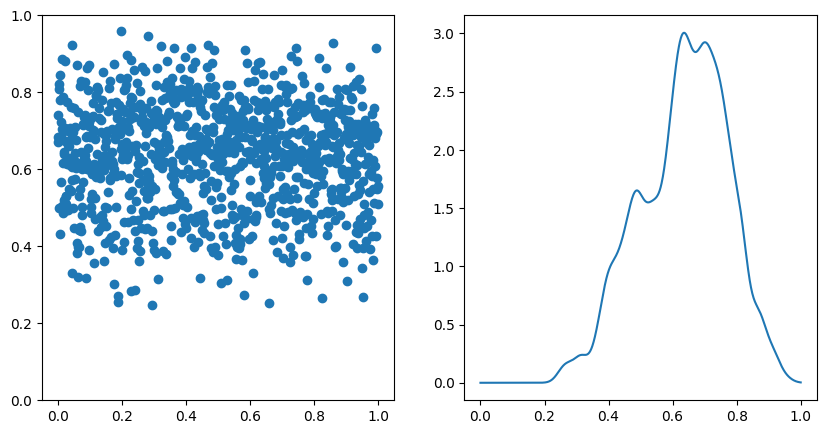

In [48]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Calculate kernel density of sampled values
kde = KernelDensity(kernel='gaussian', bandwidth=0.02).fit(sample.reshape(-1,1))
log_density = kde.score_samples(p_grid.reshape(-1,1))
density = np.exp(log_density)

# Plot 
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axs[0].scatter(p_grid, sample)
axs[0].set_ylim(0,1)
axs[1].plot(p_grid, density);

### 3.2 Sampling to summarize

How do you summarize the posterior? Common questions include:

1. Questions about intervals of *defined boundaries*
 * How much posterior probability lies below some parameter value?
 * How much posterior probability lies between two parameter values?
2. Questions about intervals of *defined probability mass*
 * Which parameter value marks teh lower 5% of the posterior probability?
 * Which range of parameter values contains 90% of the posterior probability?
3. Questions about *point estimates*
 * Which parameter value has highest posterior probability

#### 3.2.1 Intervals of defined boundaries

What is the posterior probability that the proportion of water is less than 0.5?

In [41]:
# add up posterior probability where p < 0.5
posterior[p_grid < 0.5].sum()

tensor(0.1719, dtype=torch.float64)

This is the way to do it for single parameters with grid approximation -> triker when more parameters are present

The same calculation using smaples from the posterior can be computed as the proportion (or frequency) of samples that match your criteria

In [42]:
sum(sample < 0.5) / len(sample)

np.float64(0.173)

This is generalizable to instances with more than one parameter as well. It can also be used to find how much of the posterior probability lies between 0.5 and 0.75

In [45]:
sum((sample > 0.5) & (sample < 0.75)) / len(sample)

np.float64(0.616)

#### 3.2.2 Intervals of defined mass

Intervals of defined mass - *confidence intervals* in frequentist approaches and *credibility intervals* or *compatibility intervals* - are ranges of parameter values compatible with the model and data
 * Report two parameter values that contain between them a specified amount of posterior probability, which is a probability mass

 To find the lower 80% posterior probability, you can use `np.quantile()`

In [50]:
np.quantile(sample, 0.80)

np.float64(0.7527527527527528)

To find the middle 80% find the parameter values at the 10th and 90th percentiles

In [51]:
np.quantile(sample, [0.1, 0.9])

array([0.44514515, 0.8029029 ])

These types of intervals, where equal probability mass is assigned to each tail, can also be called *percential intervals (PI)*. However, they aren't perfect, consider the following posterior distribution

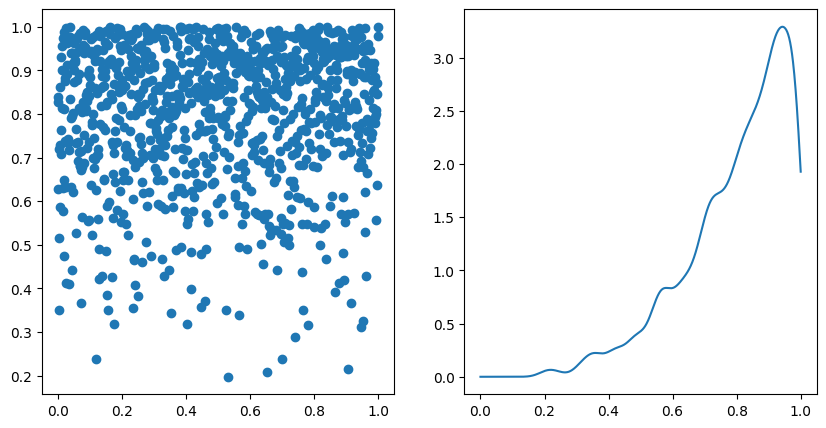

In [80]:
# Grid approximate the posterior 
p_grid = np.linspace(start=0, stop=1, num=1000)
prior = [1]*1000
likelihood = dbinom(3, 3, p_grid)
posterior = likelihood * torch.tensor(prior)
posterior = posterior / sum(posterior)

# Sample from the posterior
samples = np.random.choice(p_grid, p=posterior, size=1000, replace=True)

# Calculate kernel density of sampled values
kde = KernelDensity(kernel='gaussian', bandwidth=0.025).fit(samples.reshape(-1,1))
log_density = kde.score_samples(p_grid.reshape(-1,1))
density = np.exp(log_density)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].scatter(p_grid, samples)
axs[1].plot(p_grid, density);

In [81]:
np.quantile(samples, [0.25, 0.75])

array([0.71246246, 0.92992993])

This puts 25% of the probability mass above and below the interval, but excludes the most probable parameter values near p=1. This can mislead on the shape of the distribution

Instead you can use the *highest posterior density interval (HDPI)* - the narrowest interval containing the specified probabilty mass. You can calculate it using `numpyro.diagnostics.hdpi`

In [82]:
from numpyro.diagnostics import hpdi

hpdi(samples, prob=0.5)

array([0.84184184, 1.        ])

Disadvantages of HPDI:
 1. More computationally intensive
 2. Suffers from greater simulation variance
 3. Harder to understand (but not really)

 #### 3.2.2 Point estimates

 Choosing a single value to represent the posterior distribution discards valuable information, but sometimes you need to do it. Perhaps the most common single value to report is the *maximum a posteriori* (MAP) estimate, or the point with the highest posterior probability. If the posterior is known you can get it like so:

In [83]:
p_grid[torch.argmax(posterior)]

np.float64(1.0)

Or from samples of a posterior you can approximate it using the kernel density

In [98]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.025).fit(samples.reshape(-1,1))
log_density = kde.score_samples(p_grid.reshape(-1,1))
density = np.exp(log_density)

p_grid[np.argmax(density)]

np.float64(0.9429429429429429)

Other point measures are the mean and media

In [87]:
np.mean(samples), np.median(samples)

(np.float64(0.8021991991991991), np.float64(0.8418418418418419))

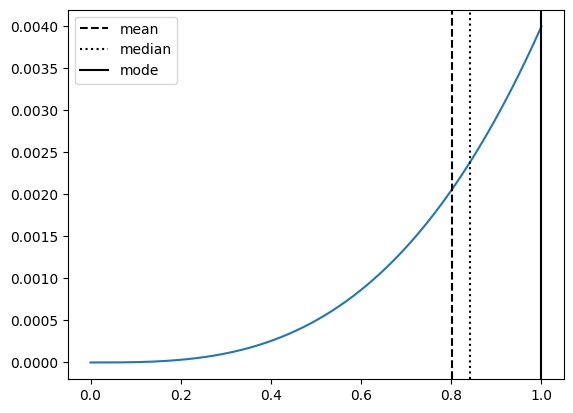

In [102]:
plt.plot(p_grid, posterior)
plt.axvline(np.mean(samples), c='black', linestyle='--', label='mean')
plt.axvline(np.median(samples), c='black', linestyle='dotted', label='median')
plt.axvline(1, c='black', label='mode')
plt.legend();

Instead of using the entire posterior as the estimate is to use a **loss function**. 
 * Loss function: A rule that tells you the cost associated with using any particular point estimate
 * Insight - different loss functions imply different point estimates

One way to calculate the loss is to subtract the prediction (e.g. mean, median, mode) from the true value. If the true value is not known - one way to do this is to use the entire posterior and do a weighted average using the posterior as weights:

In [103]:
sum(posterior*abs(0.5 - p_grid))

/var/folders/p3/9rjzbfq51zv0z_y_wpsp8w2c0000gn/T/ipykernel_39538/3043031922.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sum(posterior*abs(0.5 - p_grid))


tensor(0.3129, dtype=torch.float64)

So the loss when using 0.5 is 0.3129. Using this loss function (absolute difference) the median value minimizes loss, as shown below:

/var/folders/p3/9rjzbfq51zv0z_y_wpsp8w2c0000gn/T/ipykernel_39538/2125709260.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  loss.append(sum(posterior*abs(value - p_grid)))


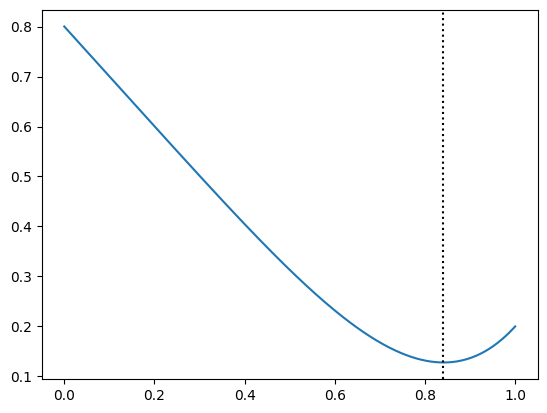

In [111]:
loss = []
for value in p_grid:
    loss.append(sum(posterior*abs(value - p_grid)))

plt.plot(p_grid, loss)
plt.axvline(p_grid[np.argmin(loss)], c='black', linestyle='dotted', label='median');

In [112]:
# Get value with minimum loss
p_grid[np.argmin(loss)], np.median(samples)

(np.float64(0.8408408408408409), np.float64(0.8418418418418419))

In order to decide upan a point estimate, a single-value summary of the posterior distribution, we need to pick a loss function. The two common loss functions are:
 1. Absolute loss $d - p$ (as above) - leads to the median
 2. Quadratic loss $(d-p)^{2}$ - leads to the mean

 ### 3.3 Sampling to simulate prediction

 Another common job for samples is to eas *simulation* of the model's implied observations. Generating implied observations from a model is useful for at least four reasons:

  1. *Model design* - We can sample from the prior to understand the implcations of the prior being used
  2. *Model checking* - After a model is updated using data, it is worth simulating implied observations, to check both whether the fit worked correctly and to investigate model behavior
  3. *Software validation* - In order to be sure that our model fitting software is working, it helps to simulate observations under a known model and then attempt to recover the values of the parameters the data were simulated under
  4. *Research design* - If you can simulate observations from your hypothesis, then you can evaluate whether the research design can be effective. In a narrow sense, this means doing *power analysis*, but the possibilities are much broader
  5. *Forecasting* - Estimates can be used to simulate new predictions for new cases and future observations. Useful for prediction and model criticism and revision.

#### 3.3.1 Dummy Data

Summary of globe tossing model:
 * Fixed true proportion of water $p$ exists - target of inference
 * Tossing globe produces observation of "water" and "land" that appere in proportion to $p$ and $1-p$, respectively

These assumptions allow us to simulate the obserations that the model implies since likelihood functions work in both directions. Because of this Bayesian models are always *generative* - capable of simulating predictions and estimating parameters from models.

Simulated data is called **Dummy Data** to indicate that it is a stand-in for actual data. For the globe tossing model, the dummy data arises from a binomial likelihood:

$$ \text{Pr}(W|N,p)=\frac{N!}{W!(N-W)!}p^{W}(1-p)^{N-W} $$

Where $W$ is an observed count of "water" and $N$ is the number of tosses. If N=2, there are three possible values for W: 0, 1, 2. Let's compute the probability of each, $p$ = 0.7:

In [121]:
dbinom([0, 1, 2], size=2, prob=np.array([0.7]))

tensor([0.0900, 0.4200, 0.4900], dtype=torch.float64)

Which means there is a 9% chance of observing $W$ = 0, a 42% chance of observing $W$ = 1, and a 49% chance of observing $W$ = 2, with a value of $p$ = 0.7

We can also simulate observations using these probabilities by sampling from the distribution described above:

In [206]:
def rbinom(n: int, size: int, prob: int | list | np.ndarray):
    """Recreation of rbinom function using PyTorch and Pyro"""
    m = distr.Binomial(size, probs=torch.tensor(prob))
    return m.sample((n,))

In [207]:
torch.manual_seed(42)
rbinom(1, size=2, prob=0.7)

tensor([2.])

This means that in 2 tosses, we see whatever is output (in this case "2") waters. We can also generate more than one simulation:

In [209]:
torch.manual_seed(23)
rbinom(10, size=2, prob=0.7)

tensor([2., 2., 1., 1., 2., 0., 2., 1., 2., 2.])

Lets generate 100000 dummy observations and verify that each value appears in proportion to its likelihood

In [212]:
dummy_w = rbinom(100000, size=2, prob=0.7)
obs, counts = torch.unique(dummy_w, return_counts=True)
counts/len(dummy_w)

tensor([0.0890, 0.4204, 0.4906])

Let's now do it for nine tosses, like we did for sampling the posterior and plot the results

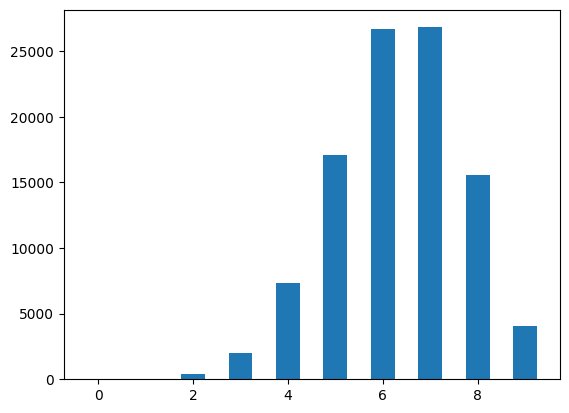

In [262]:
dummy_w = rbinom(100000, size=9, prob=0.7)
obs, counts = torch.unique(dummy_w, return_counts=True)
plt.bar(obs, counts, width=0.5);

#### 3.3.2 Model checking

**Model checking** means:
 1. Ensuring the model fitting worked correctly
 2. Evaluating the adequacy of a model for some purpose

Once a model is conditioned on data, you can simulate to examing the model's empirical expectations

##### 3.3.2.1 Did the software work

Check for correspondance between the implied predictions - aka *retrodictions* - and the data used to fit the model. Exact matches are not expected (or desired) and there is no way to truly know if the software works correctly, but it can help catch simple mistakes.

##### 3.3.2.2 Is the model adequate?

Goal - assess exactly how the model fails to describe the data, as a path towards model comprehension, revision and improvement. For now need to learn how to combine sampling of simulated observations with sampling parameters from the posterior distributions

Lets do basic model checks using simulated observations for the globe tossing model. Observations are counts of water, over tosses of the globe. Implied predictiosn of the model are uncertain in two ways: 
 1. Observation uncertainty - there is uncertainty in the predicted observations, becuase even if you know $p$ with certainty, you won't know the next globe toss with certainty
 2. Uncertainty about $p$ - Posterior distribution embodies this uncertainty

We would like to *propagate* the parameter uncertainty - carry it forward - as we evaluate the implied predictions
 * Do so by averaging over the posterior density for $p$ while computing predictions
     * compute the smapling distribution (simulations) of outcomes at each value of $p$, then average all prediction distributions together using the posterior probabilities of each value of $p$ to get a **Posterior Predictive Distribution**
     * Resulting distribution is for predictions but incorporates uncertainty for $p$

How do we do this? Replace the single probability value for `rbinom()` with the samples we took from the posterior. That way, we are simulating over every sampled value from the posterior

In [254]:
w = rbinom(100000, size=9, prob=sample)

This gives you a 2d tensor -> each 'row' is simulated data for the value of sampled posterior and so you can combine them to get the posterior predictive distributions (since they appear in proportion to their posterior probabilities)

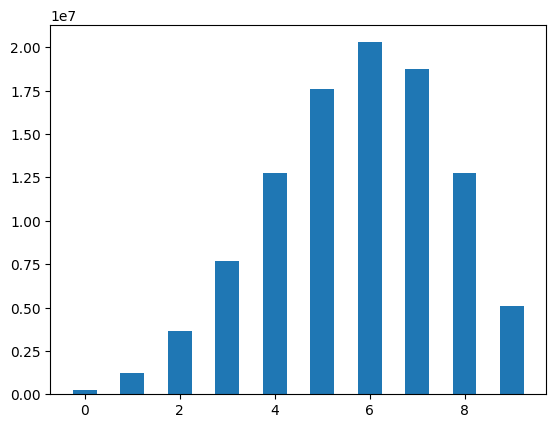

In [261]:
# Plot the posterior predictive distribution

obs, counts = torch.unique(w.flatten(), return_counts=True)
plt.bar(obs, counts, width=0.5);

This posterior predictive distribution assumes that tosses of the globe are independent of each other - but that might not be the case. Wwith the goal of seeking out aspects of prediction in which the model fails, lets look at the data in two different ways:

1. Length of the longest run of either water or land - gives crude measure of the correlation between tosses.
2. Number of times in the data that the smaple switches from water to land or from land to water - another measure of correlation between samples

### 3.5 Practice

The easy problems use the code from the next cell block

In [264]:
p_grid = np.linspace(start=0, stop=1, num=1000)
prior = [1]*1000
likelihood = dbinom(6, 9, p_grid)
posterior = likelihood*torch.tensor(prior)
posterior = posterior / sum(posterior)

np.random.seed(100)
samples = np.random.choice(p_grid, p=posterior, size=1000, replace=True)

3E1. How much posterior probability lies below $p$ = 0.2

In [275]:
sum(samples < 0.2) / 1000


np.float64(0.002)

3E2. How much posterior probability lies above $p$ = 0.8?

In [266]:
sum(samples > 0.8) / len(samples)

np.float64(0.122)

3E3. How much posterior probability lies between $p$ = 0.2 and $p$ = 0.8?

In [267]:
sum((samples > 0.2) & (samples < 0.8)) / len(samples)

np.float64(0.876)

3E4. 20% of the posterior probability lies below which value of $p$?

In [269]:
np.quantile(samples, 0.2)

np.float64(0.5165165165165165)

3E5. 20% of the posterior probability lies above which value of $p$?

In [270]:
np.quantile(samples, 0.8)

np.float64(0.7587587587587588)

3E6. Which values of $p$ contain the narrowiest interval equal to 66% of the posterior probability?

In [271]:
hpdi(samples, prob=0.66)

array([0.50550551, 0.77377377])

3E7. Which values of $p$ contain 66% of the posterior probability, assuming equal posterior probability both below and above the interval?

In [272]:
np.quantile(samples, [0.17, 0.83])

array([0.5005005 , 0.77177177])